In [2]:
import scanpy as sc
import cellrank as cr
from cellrank.kernels import RealTimeKernel
from moscot.problems.time import TemporalProblem
import matplotlib.pyplot as plt

In [ ]:
# import scipy.sparse
# import numpy as np
# import pygpcca._gpcca as _gpcca_mod
# from pygpcca._sorted_schur import sorted_schur

# def _patched_do_schur(P, eta, m, z, method, tol_krylov=1e-16):
#     if eta is None:
#         P_bar = P
#     else:
#         sqrt_eta = np.sqrt(eta)
#         if scipy.sparse.issparse(P):
#             D = scipy.sparse.diags(sqrt_eta)
#             D_inv = scipy.sparse.diags(1.0 / sqrt_eta)
#             P_bar = D.dot(P).dot(D_inv)
#         else:
#             P_bar = np.diag(sqrt_eta).dot(P).dot(np.diag(1.0 / sqrt_eta))

#     R, Q, eigenvalues = sorted_schur(P_bar, m, z, method, tol_krylov=tol_krylov)
#     # rest of the original function — orthonormalize Q
#     return _gpcca_mod._do_schur.__wrapped__(P, eta, m, z, method, tol_krylov)

# # replace the function inside the module
# _gpcca_mod._do_schur = _patched_do_schur

In [2]:
adata_pdgfra = sc.read('../results/pdgfra_new/pdgfra_gpcca.h5ad')
adata_pdgfra

AnnData object with n_obs × n_vars = 35403 × 18262
    obs: 'sample', 'instance_id', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden_harmony_0.6', 'leiden_harmony_0.7', 'cell_type', 'cell_type_labels', 'ebf2+_sox9+_col2a1+', 'ebf2+_sox9+_col2a1-', 'ebf2_sox9_col2a1', 'fpdev_reclustered_leiden_0.4', 'fpdev_reclustered_leiden_0.5', 'fpdev_reclustered_leiden_0.6', 'tdtom_reclustered_leiden_0.4', 'tdtom_reclustered_leiden_0.5', 'tdtom_reclustered_leiden_0.6', 'pdgfra', 'array_col', 'array_row', 'geometry', 'timepoints', 'tissue', 'cell_type_tdtom_0.4', 'pdgfra+', 'ebf2_sox9_pdgfra', 'pdgfra_cell_types', 'tdtom_0.6_cell_types', 'tdtomato+', 'pdgfra+_tdtomato+', 'proliferation', 'apoptosis', 'timepoints_float', 'term_states_fwd', 'term_states_fwd_probs'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 

## pdgfra w/ cflare

In [ ]:
sc.pl.umap(adata_pdgfra, color=['timepoints', 'pdgfra_cell_types'])

In [ ]:
# rebuild kernel from stored transition matrix
tmk = RealTimeKernel.from_adata(adata_pdgfra, key="T_fwd")

In [ ]:
# rebuild estimator and fit from stored data
g = cr.estimators.CFLARE(tmk)
g.fit(k=10)
g.predict(cluster_key="pdgfra_cell_types", method='kmeans', n_clusters_kmeans=10)

In [ ]:
# plot
g.plot_macrostates(which='terminal', discrete=False, legend_loc="right")

In [ ]:
# compute fate probabilities
g.compute_fate_probabilities()

In [ ]:
g.plot_fate_probabilities(same_plot=False, cmap='Blues')

In [ ]:
sc.pl.umap(adata_pdgfra, color=['timepoints', 'pdgfra_cell_types'])

## gpcca with pdgfra

In [3]:
adata_pdgfra_gpcca = adata_pdgfra.copy()

In [4]:
tp = TemporalProblem(adata_pdgfra_gpcca)
tp = tp.score_genes_for_marginals(
    gene_set_proliferation="mouse", gene_set_apoptosis="mouse"
)

       'Lrmp', 'Rpl18', 'Rps12', 'Rps27l', 'Rrp8'],
      dtype='object')


In [5]:
tp = tp.prepare(time_key="timepoints_float")

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  


In [6]:
tp = tp.solve(epsilon=1e-3, tau_a=0.95, scale_cost="mean")

INFO     Solving `2` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(4836, 15158)].                                 
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(15158, 15409)].                                


In [ ]:
tmk = RealTimeKernel.from_moscot(tp)

In [8]:
tmk.compute_transition_matrix(self_transitions="all", conn_weight=0.2, threshold="auto")

  0%|          | 0/2 [00:00<?, ?time pair/s]

RealTimeKernel[n=35403, threshold='auto', self_transitions='all']

  0%|          | 0/100 [00:00<?, ?sim/s]

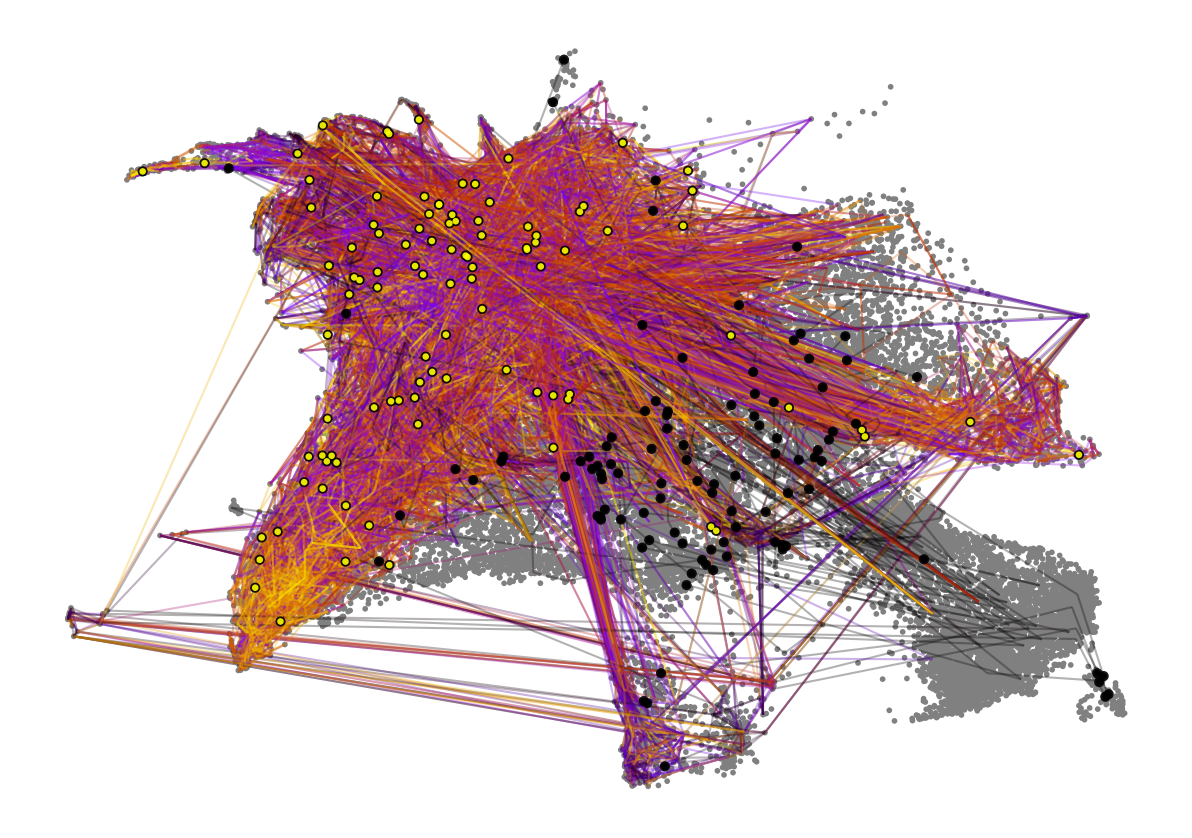

In [9]:
# visualize recovered dynamics
tmk.plot_random_walks(
    max_iter=500,
    start_ixs={"timepoints_float": 11.5},
    basis="X_umap",
    seed=0,
    dpi=150,
    size=30,
    figsize=(10,7)
)

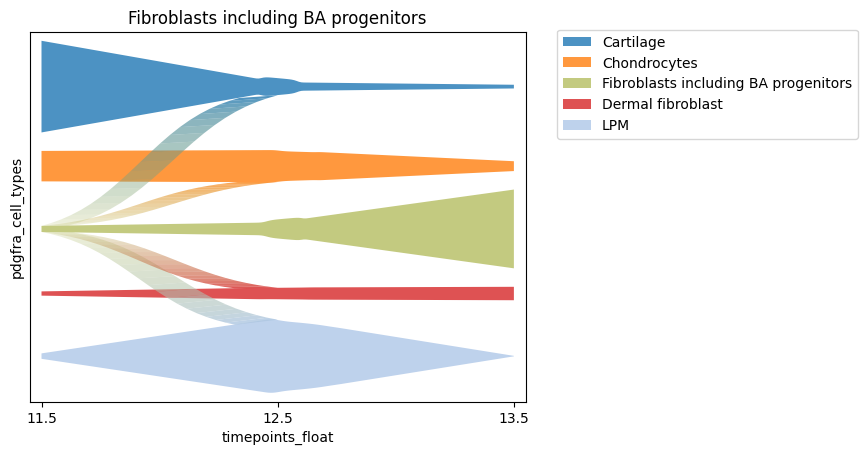

In [24]:
# probability mass flow graphs
ax = tmk.plot_single_flow(
    cluster_key="pdgfra_cell_types",
    time_key="timepoints_float",
    cluster="Fibroblasts including BA progenitors",
    min_flow=0.1,
    xticks_step_size=1,
    show=False,
)

_ = ax.set_xticklabels(ax.get_xticklabels())

In [10]:
# initialize gpcca estimator
g = cr.estimators.GPCCA(tmk)
print(g)

GPCCA[kernel=RealTimeKernel[n=35403], initial_states=None, terminal_states=None]


In [ ]:
# # macrostates
# g.fit(cluster_key="pdgfra_cell_types", n_states=[8, 10])
# g.plot_macrostates(which="all", discrete=True, legend_loc="right", s=100)

In [11]:
g.compute_schur(method='krylov')

GPCCA[kernel=RealTimeKernel[n=35403], initial_states=None, terminal_states=None]

In [22]:
g.compute_macrostates(n_states=[10,12], cluster_key="pdgfra_cell_types")

GPCCA[kernel=RealTimeKernel[n=35403], initial_states=None, terminal_states=None]

/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


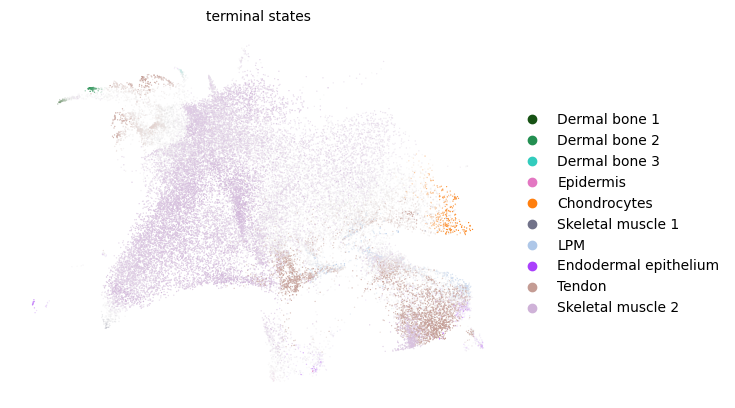

In [15]:
# predict terminal states
g.predict_terminal_states()
g.plot_macrostates(which="terminal", legend_loc="right", discrete=False)

/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


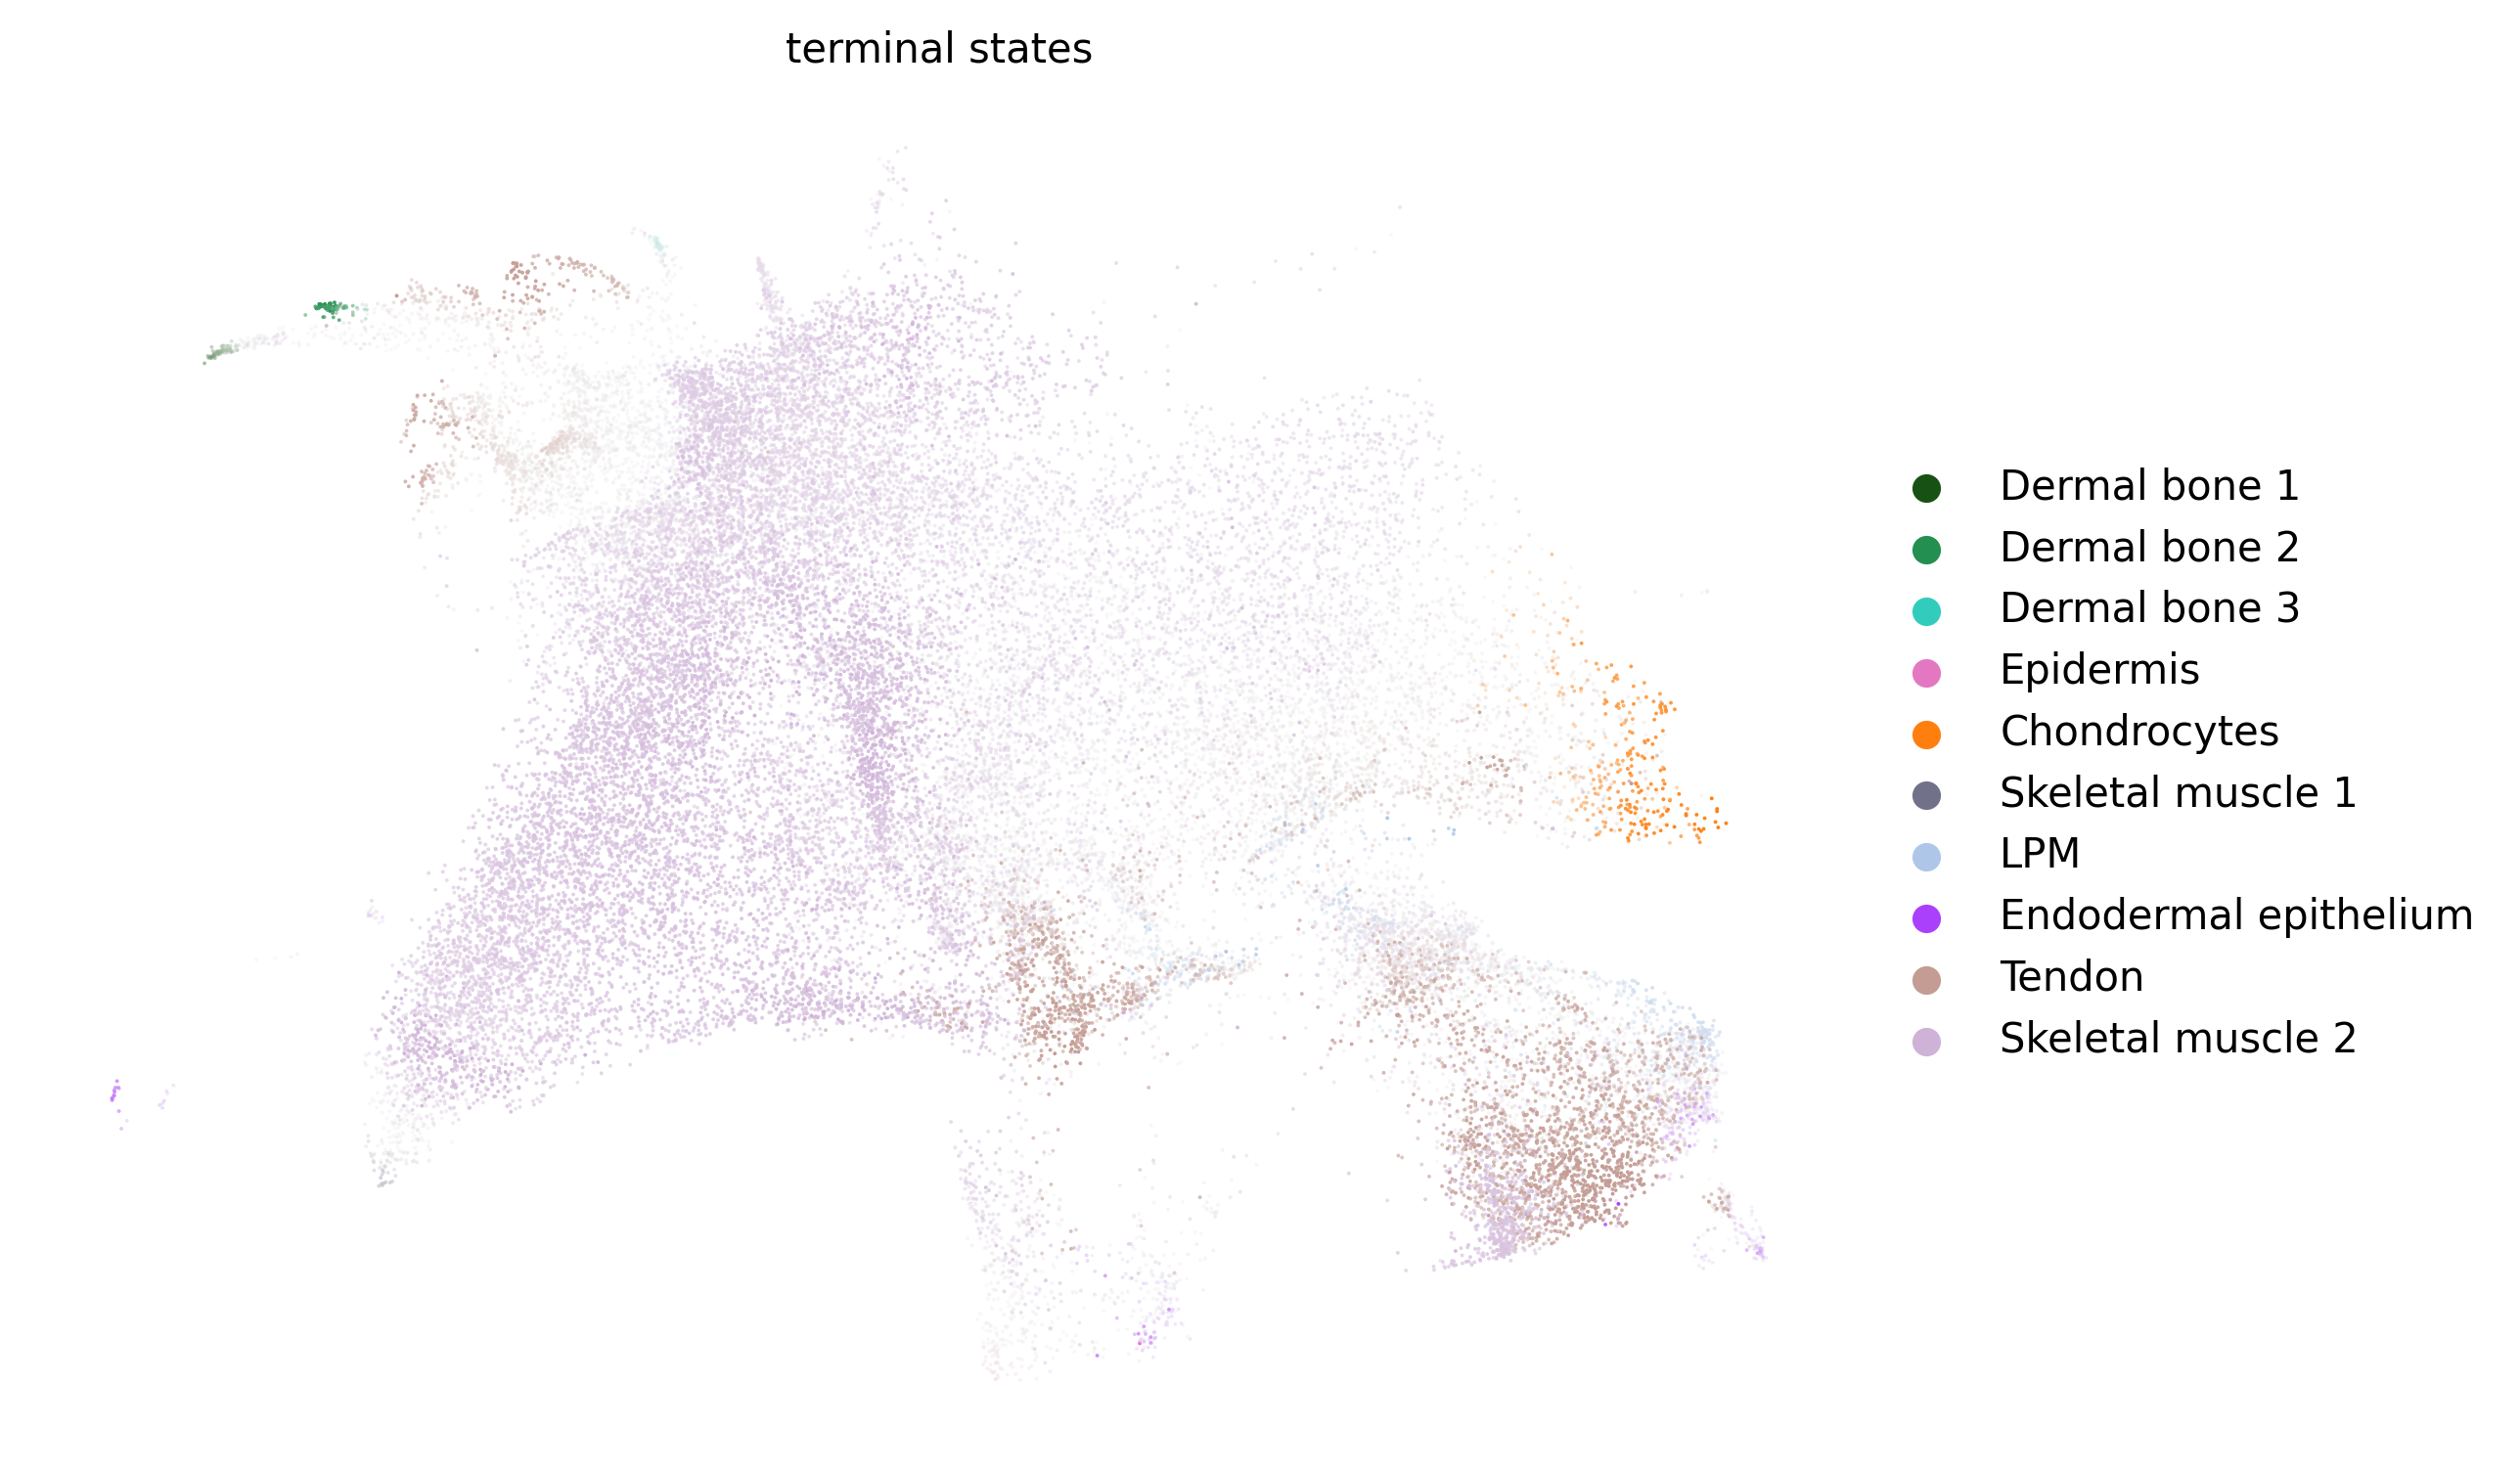

<Figure size 640x480 with 0 Axes>

In [17]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
g.plot_macrostates(which="terminal", legend_loc="right", discrete=False, ax=ax)
plt.show()

/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


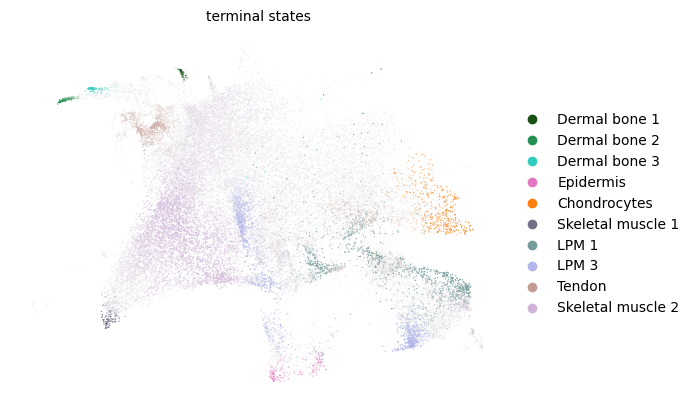

In [23]:
# predict terminal states - n_states[10,12]
g.predict_terminal_states()
g.plot_macrostates(which="terminal", legend_loc="right", discrete=False)

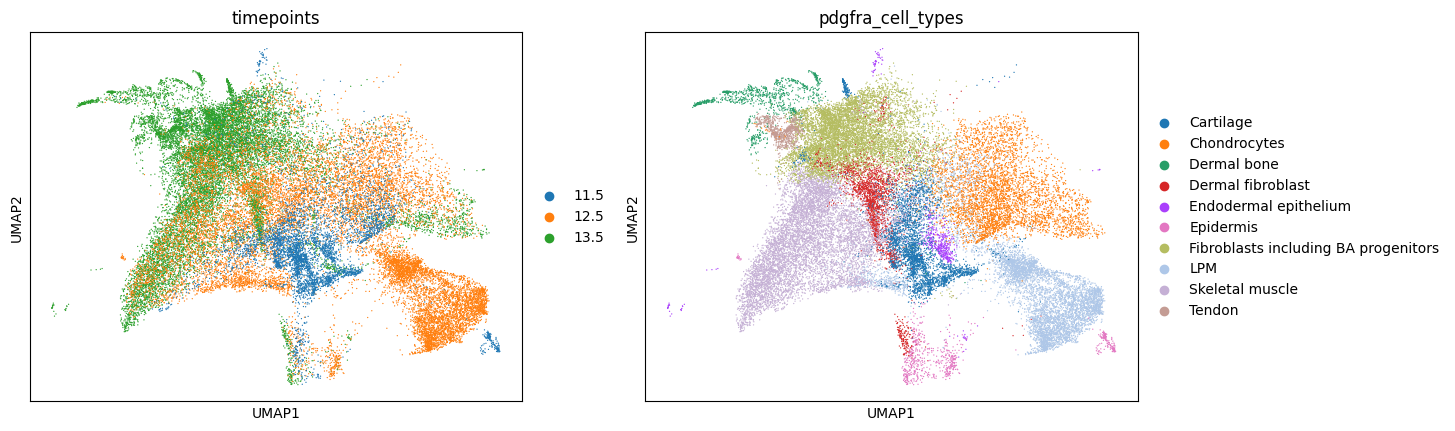

In [21]:
sc.pl.umap(adata_pdgfra_gpcca, color=['timepoints', 'pdgfra_cell_types'])

In [18]:
g.compute_fate_probabilities()

  0%|          | 0/10 [00:00<?, ?/s]

In [19]:
DRIVER_CLUSTERS = [
    "Fibroblasts including BA progenitors",
    "Chondrocytes",
    "Endodermal epithelium",
    "Dermal bone",
    "Skeletal muscle",
    "LPM",
    "Epidermis",
    "Dermal fibroblast",
    "Cartilage",
    "Tendon",
]

BA_df = g.compute_lineage_drivers(
    lineages=['Fibroblasts including BA progenitors'], cluster_key='pdgfra_cell_types', clusters=DRIVER_CLUSTERS
)
BA_df.head(20)

KeyError: "Invalid lineage name `'Fibroblasts including BA progenitors'`. Valid names are: `[np.str_('Dermal bone_1'), np.str_('Dermal bone_2'), np.str_('Dermal bone_3'), np.str_('Epidermis'), np.str_('Chondrocytes'), np.str_('Skeletal muscle_1'), np.str_('LPM'), np.str_('Endodermal epithelium'), np.str_('Tendon'), np.str_('Skeletal muscle_2')]`."

## tdtom gpcca

In [25]:
adata_tdtom = sc.read('../results/tdtom/tdtom_gpcca.h5ad')
adata_tdtom

AnnData object with n_obs × n_vars = 36092 × 18262
    obs: 'sample', 'instance_id', 'region', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden_harmony_0.6', 'leiden_harmony_0.7', 'cell_type', 'cell_type_labels', 'ebf2+_sox9+_col2a1+', 'ebf2+_sox9+_col2a1-', 'ebf2_sox9_col2a1', 'fpdev_reclustered_leiden_0.4', 'fpdev_reclustered_leiden_0.5', 'fpdev_reclustered_leiden_0.6', 'tdtom_reclustered_leiden_0.4', 'tdtom_reclustered_leiden_0.5', 'tdtom_reclustered_leiden_0.6', 'pdgfra', 'array_col', 'array_row', 'geometry', 'timepoints', 'tissue', 'cell_type_tdtom_0.4', 'pdgfra+', 'ebf2_sox9_pdgfra', 'pdgfra_cell_types', 'tdtom_0.6_cell_types', 'tdtomato+', 'pdgfra+_tdtomato+', 'proliferation', 'apoptosis', 'timepoints_float', 'term_states_fwd', 'term_states_fwd_probs'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 

In [26]:
tp_tdtom = TemporalProblem(adata_tdtom)
tp_tdtom = tp_tdtom.score_genes_for_marginals(
    gene_set_proliferation="mouse", gene_set_apoptosis="mouse"
)
tp_tdtom = tp_tdtom.prepare(time_key="timepoints_float")
tp_tdtom = tp_tdtom.solve(epsilon=1e-3, tau_a=0.95, scale_cost="mean")
tmk_tdtom = RealTimeKernel.from_moscot(tp_tdtom)
tmk_tdtom.compute_transition_matrix(self_transitions="all", conn_weight=0.2, threshold="auto")

       'Lrmp', 'Rpl18', 'Rps12', 'Rps27l', 'Rrp8'],
      dtype='object')
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Solving `2` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(4310, 13146)].                                 
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(13146, 18636)].                                


  0%|          | 0/2 [00:00<?, ?time pair/s]

RealTimeKernel[n=36092, threshold='auto', self_transitions='all']

  0%|          | 0/100 [00:00<?, ?sim/s]

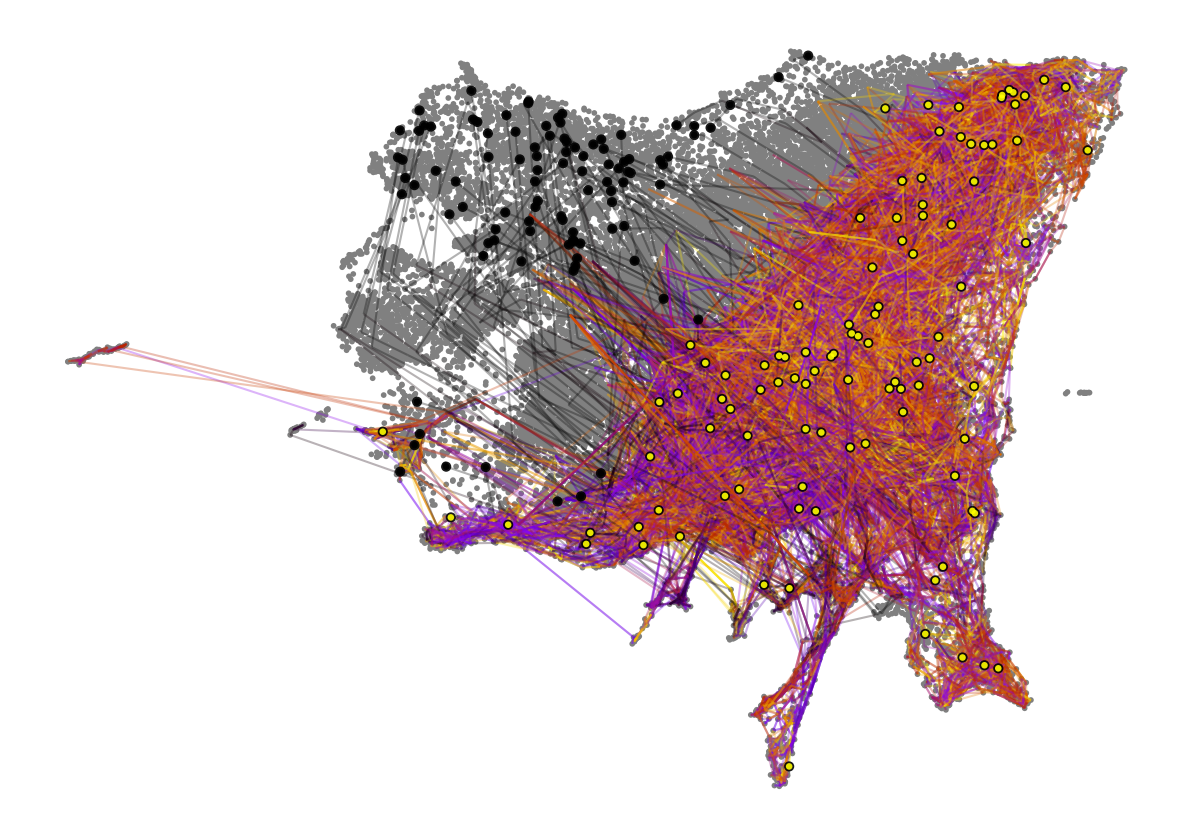

In [27]:
# visualize recovered dynamics
tmk_tdtom.plot_random_walks(
    max_iter=500,
    start_ixs={"timepoints_float": 11.5},
    basis="X_umap",
    seed=0,
    dpi=150,
    size=30,
    figsize=(10,7)
)

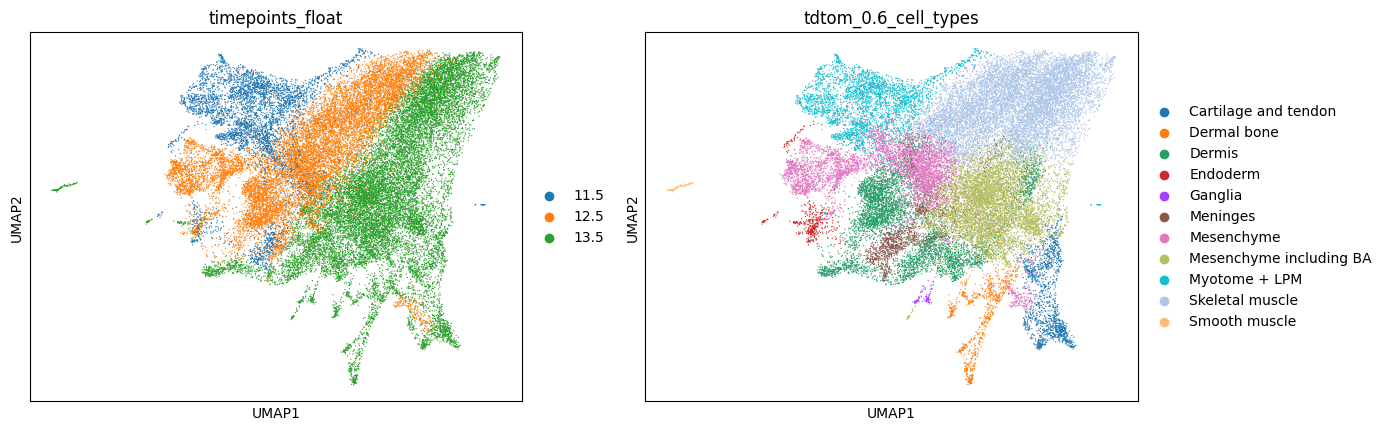

In [28]:
sc.pl.umap(adata_tdtom, color=['timepoints_float', 'tdtom_0.6_cell_types'])

/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


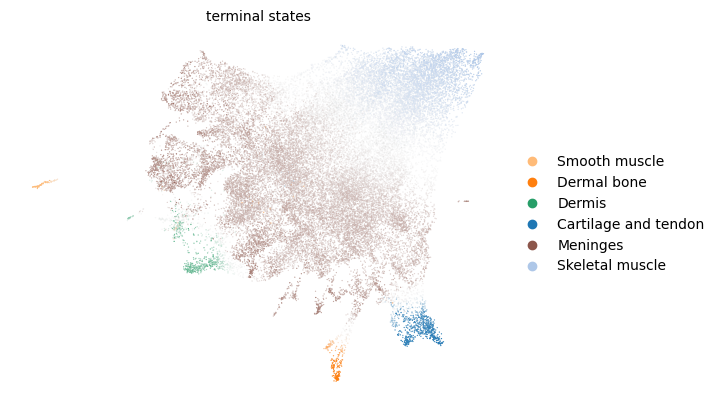

In [48]:
g_tdtom = cr.estimators.GPCCA(tmk_tdtom)
g_tdtom.compute_schur(method='krylov')
g_tdtom.compute_macrostates(n_states=6, cluster_key="tdtom_0.6_cell_types")
g_tdtom.predict_terminal_states()
g_tdtom.plot_macrostates(which="terminal", legend_loc="right", discrete=False)

/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/utils.py:1396: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/utils.py:1397: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=gp_size, marker=".", c=gp_color, zorder=zord - 1, **kwargs)


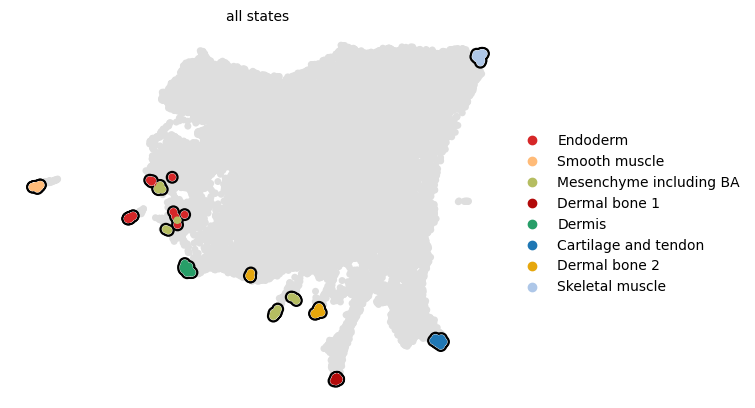

In [43]:
g_tdtom.plot_macrostates(which="all", discrete=True, legend_loc="right", s=100)

/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/utils.py:1396: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/opt/anaconda3/envs/single-cell/lib/python3.13/site-packages/scvelo/plotting/utils.py:1397: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=gp_size, marker=".", c=gp_color, zorder=zord - 1, **kwargs)


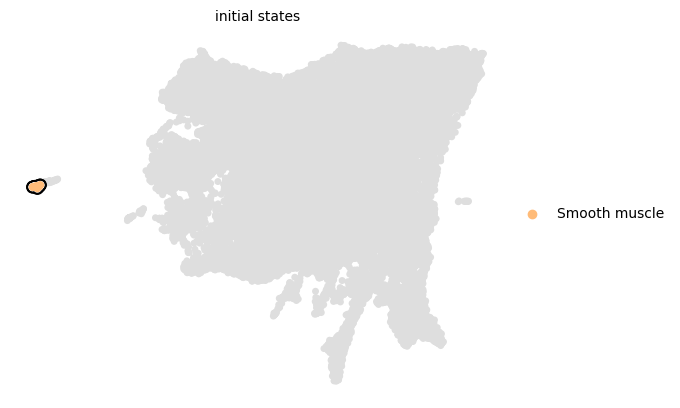

In [37]:
g_tdtom.predict_initial_states(allow_overlap=True)
g_tdtom.plot_macrostates(which="initial", discrete=True, legend_loc="right", s=100)

# original analysis
take `combined_samples_analyzed_one_canvas_labeled.ipynb` and redo trajectory